In [89]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [90]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

In [91]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [92]:
df = pd.read_csv('./data/Housing-selected-columns.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,yes,no,no,no,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes
2,12250000,9960,3,2,2,yes,no,yes,no,no
3,12215000,7500,4,2,2,yes,no,yes,no,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes


In [93]:
df.shape

(545, 10)

In [94]:
df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning']

In [95]:
df.isnull().sum()

price              0
area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
dtype: int64

In [96]:
df.duplicated().sum()

np.int64(0)

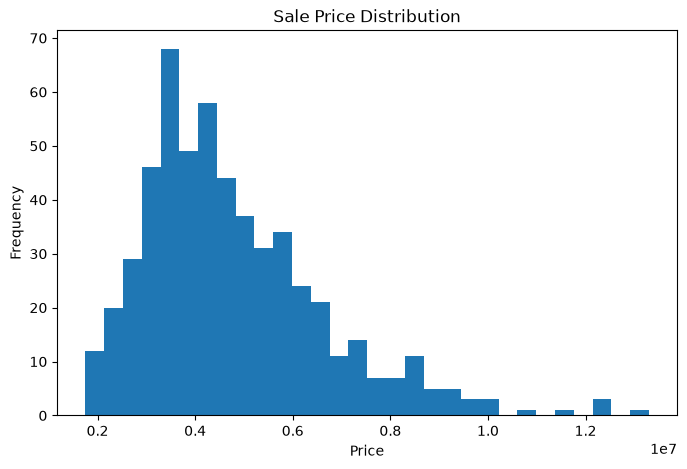

In [97]:
plt.figure(figsize=(8,5))
plt.hist(
    df["price"],
    bins=30
)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Sale Price Distribution")
plt.show()

In [98]:
X = df.drop(columns=['price'])
y = df['price']

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            545 non-null    int64
 1   area             545 non-null    int64
 2   bedrooms         545 non-null    int64
 3   bathrooms        545 non-null    int64
 4   stories          545 non-null    int64
 5   mainroad         545 non-null    str  
 6   guestroom        545 non-null    str  
 7   basement         545 non-null    str  
 8   hotwaterheating  545 non-null    str  
 9   airconditioning  545 non-null    str  
dtypes: int64(5), str(5)
memory usage: 49.0 KB


In [100]:
numerical_columns = X.select_dtypes(
    include=['int64', 'float64']
).columns
print(numerical_columns.tolist())

categorical_columns = X.select_dtypes(
    include=['object']
).columns
print(categorical_columns.tolist())

['area', 'bedrooms', 'bathrooms', 'stories']
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning']


/var/folders/4q/rmb_b9l12v51q3_6z0q6qwj40000gn/T/ipykernel_62534/2576175245.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [101]:
X[numerical_columns].isnull().sum().sort_values(ascending=False)

area         0
bedrooms     0
bathrooms    0
stories      0
dtype: int64

In [102]:
categorical_columns.isnull().sum()
X = pd.get_dummies(
    X, 
    columns=categorical_columns,
    drop_first=True
)
X = X.astype(float)

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [104]:
result = pd.DataFrame({
    "Actual " : y_test,
    "Predicted" : y_pred
})
result.head(10)

,Actual,Predicted
316,4060000,4.830423e+06
77,6650000,7.126551e+06
360,3710000,3.508275e+06
90,6440000,4.668323e+06
493,2800000,3.675363e+06
209,4900000,4.543827e+06
176,5250000,5.714299e+06
249,4543000,5.322541e+06
516,2450000,3.448858e+06
426,3353000,2.777178e+06


In [105]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2Score = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squred Error : ", mse)
print("Mean Absolute Error : ", mae)
print("R2 Score : ", r2Score)
print("Rmse : ", rmse)

Mean Squred Error :  2112073159657.7197
Mean Absolute Error :  1092472.5984510903
R2 Score :  0.5821458488624587
Rmse :  1453297.3404151401


In [106]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1, verbose=1)
print(cv_scores)
print(cv_scores.mean())

[0.66532085 0.63031678 0.57078453 0.56507314 0.56926807]
0.6001526752213037


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished


In [107]:
param_grid = {
    'n_estimators': [100, 150, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1,2,3,4,5],
    'subsample': [0.7, 0.8, 1.0]
}

best_model = GridSearchCV(
    estimator=GradientBoostingRegressor(),
    param_grid=param_grid,
    cv=5, 
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_aut

In [114]:
y_pred_best = best_model.predict(X_test)

final_mse = mean_squared_error(y_test, y_pred_best)
final_mae = mean_absolute_error(y_test, y_pred_best)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_best)

print("Best K Value : ", best_model.best_score_)
print("Best Mean Squred Error : ", final_mse)
print("Best Mean Absolute Error : ", final_mae)
print("Best R2 Score : ", final_r2)
print("Best Adjusted R2 Score : ", final_rmse)


Best K Value :  0.6133417730753681
Best Mean Squred Error :  2077827742732.969
Best Mean Absolute Error :  1059898.0571632413
Best R2 Score :  0.5889209880445512
Best Adjusted R2 Score :  1441467.2187507313
